In [ ]:
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.append("/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis")
from cbm_datasets import CUB_112, CUB_312, get_transform_cub  # Import anpassen

In [ ]:
# Pfade anpassen!
ROOT_DIR = "/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/datasets/CUB_200_2011"

# Transform ohne Crop für Masken-Generierung ist oft sicherer,
# aber wenn du später auf gecroppten Bildern trainierst, MUSST du hier 
# exakt denselben Transform (Crop/Resize) nutzen wie im Training!
transform = get_transform_cub(img_size=256, center_crop_size=None) # oder mit Crop

dataset = CUB_312(root_dir=ROOT_DIR, mode="train", transform=transform, concept_masks_scale=None) # Modus egal wenn du alles willst

# Example

In [ ]:
# Example
bird = dataset[130]
bird.keys()

dict_keys(['class_idx', 'image_id', 'image', 'concepts', 'concept_coords', 'concept_point_mask', 'labels', 'mask_foreground'])

In [ ]:
def plot_concept_prompts_single_label(
    sample,
    concept_names,
    figsize=(12, 10),
    margin=0.25,
    max_concepts=None,
):
    """
    Plot concept prompt keypoints with ONE label per concept
    and arrows pointing to all corresponding locations.
    """

    # --- Image ---
    img = sample["image"].transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = (img * std + mean).clip(0, 1)

    coords = sample["concept_coords"]
    point_mask = sample["concept_point_mask"]
    active = sample["concepts"]

    H, W, _ = img.shape

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis("off")

    # Platz für Side-Labels
    ax.set_xlim(-margin * W, (1 + margin) * W)
    ax.set_ylim(H, 0)

    concepts = []

    # --- Collect per-concept keypoints ---
    for c_idx in range(len(active)):
        if active[c_idx] == 0:
            continue

        num_points = int(point_mask[c_idx].sum())
        if num_points <= 1:
            continue  # ← HIER der Trick

        points = []
        for p_idx in range(coords.shape[1]):
            if point_mask[c_idx, p_idx] == 1:
                x, y = coords[c_idx, p_idx]
                points.append((float(x), float(y)))

        if points:
            concepts.append(dict(
                c_idx=c_idx,
                name=concept_names[c_idx],
                points=points,
            ))

    if max_concepts is not None:
        concepts = concepts[:max_concepts]

    # Split left / right by mean x
    left, right = [], []
    for c in concepts:
        xs = [p[0] for p in c["points"]]
        if np.mean(xs) < W / 2:
            left.append(c)
        else:
            right.append(c)

    # --- Draw ---
    def draw(concepts, side):
        if not concepts:
            return

        concepts = sorted(concepts, key=lambda c: np.mean([p[1] for p in c["points"]]))
        y_texts = np.linspace(0.08 * H, 0.92 * H, len(concepts))

        if side == "left":
            x_text = -0.05 * W
            ha = "right"
        else:
            x_text = 1.05 * W
            ha = "left"

        for c, y_text in zip(concepts, y_texts):
            # label
            ax.text(
                x_text,
                y_text,
                c["name"],
                fontsize=30,
                color="white",
                ha=ha,
                va="center",
                bbox=dict(
                    facecolor="black",
                    alpha=0.65,
                    edgecolor="none",
                    boxstyle="round,pad=0.2",
                ),
                clip_on=False,
                zorder=4,
            )

            # arrows to all points
            for (x, y) in c["points"]:
                ax.scatter(
                    x, y,
                    s=55,
                    edgecolors="white",
                    linewidths=1.2,
                    zorder=3,
                )
                ax.annotate(
                    "",
                    xy=(x, y),
                    xytext=(x_text, y_text),
                    arrowprops=dict(
                        arrowstyle="->",
                        linewidth=0.8,
                        alpha=0.7,
                    ),
                    clip_on=False,
                    zorder=2,
                )

    draw(left, "left")
    draw(right, "right")

    ax.set_title(
        f"Concept Prompt Keypoints (One Label per Concept)",
        fontsize=12,
    )
    
    return fig


In [ ]:
def plot_concept_prompts_side_labels(
    sample,
    concept_names,
    figsize=(12, 10),
    margin=0.25,
    max_labels=None,
):
    img = sample["image"].transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = (img * std + mean).clip(0, 1)

    coords = sample["concept_coords"]
    point_mask = sample["concept_point_mask"]
    active = sample["concepts"]

    H, W, _ = img.shape

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis("off")

    # 🔴 WICHTIG: Platz links & rechts schaffen
    ax.set_xlim(-margin * W, (1 + margin) * W)
    ax.set_ylim(H, 0)

    left_items, right_items = [], []

    for c_idx in range(len(active)):
        if active[c_idx] == 0:
            continue
        for p_idx in range(coords.shape[1]):
            if point_mask[c_idx, p_idx] != 1:
                continue

            x, y = coords[c_idx, p_idx]
            item = dict(x=float(x), y=float(y), name=concept_names[c_idx])

            if x < W / 2:
                left_items.append(item)
            else:
                right_items.append(item)

    if max_labels:
        left_items = left_items[: max_labels // 2]
        right_items = right_items[: max_labels // 2]

    def draw(items, side):
        if not items:
            return

        items = sorted(items, key=lambda d: d["y"])
        y_texts = np.linspace(0.05 * H, 0.95 * H, len(items))

        if side == "left":
            x_text = -0.05 * W
            ha = "right"
        else:
            x_text = 1.05 * W
            ha = "left"

        for item, y_t in zip(items, y_texts):
            ax.scatter(
                item["x"], item["y"],
                s=55, edgecolors="white", linewidths=1.2, zorder=3
            )

            ax.plot(
                [item["x"], x_text],
                [item["y"], y_t],
                linewidth=0.8,
                alpha=0.7,
                zorder=2,
                clip_on=False,
            )

            ax.text(
                x_text, y_t,
                item["name"],
                fontsize=30,
                color="white",
                ha=ha,
                va="center",
                bbox=dict(
                    facecolor="black",
                    alpha=0.65,
                    edgecolor="none",
                    boxstyle="round,pad=0.2",
                ),
                zorder=4,
                clip_on=False,
            )

    draw(left_items, "left")
    draw(right_items, "right")

    ax.set_title(
        f"Concept Prompt Keypoints with Side Labels (Class {int(sample['class_idx'])})",
        fontsize=12,
    )

    return fig


In [ ]:
image = bird['image']

# unnormalized image with image transform reversed


image.shape
plt.ioff() # Schaltet den interaktiven Modus aus

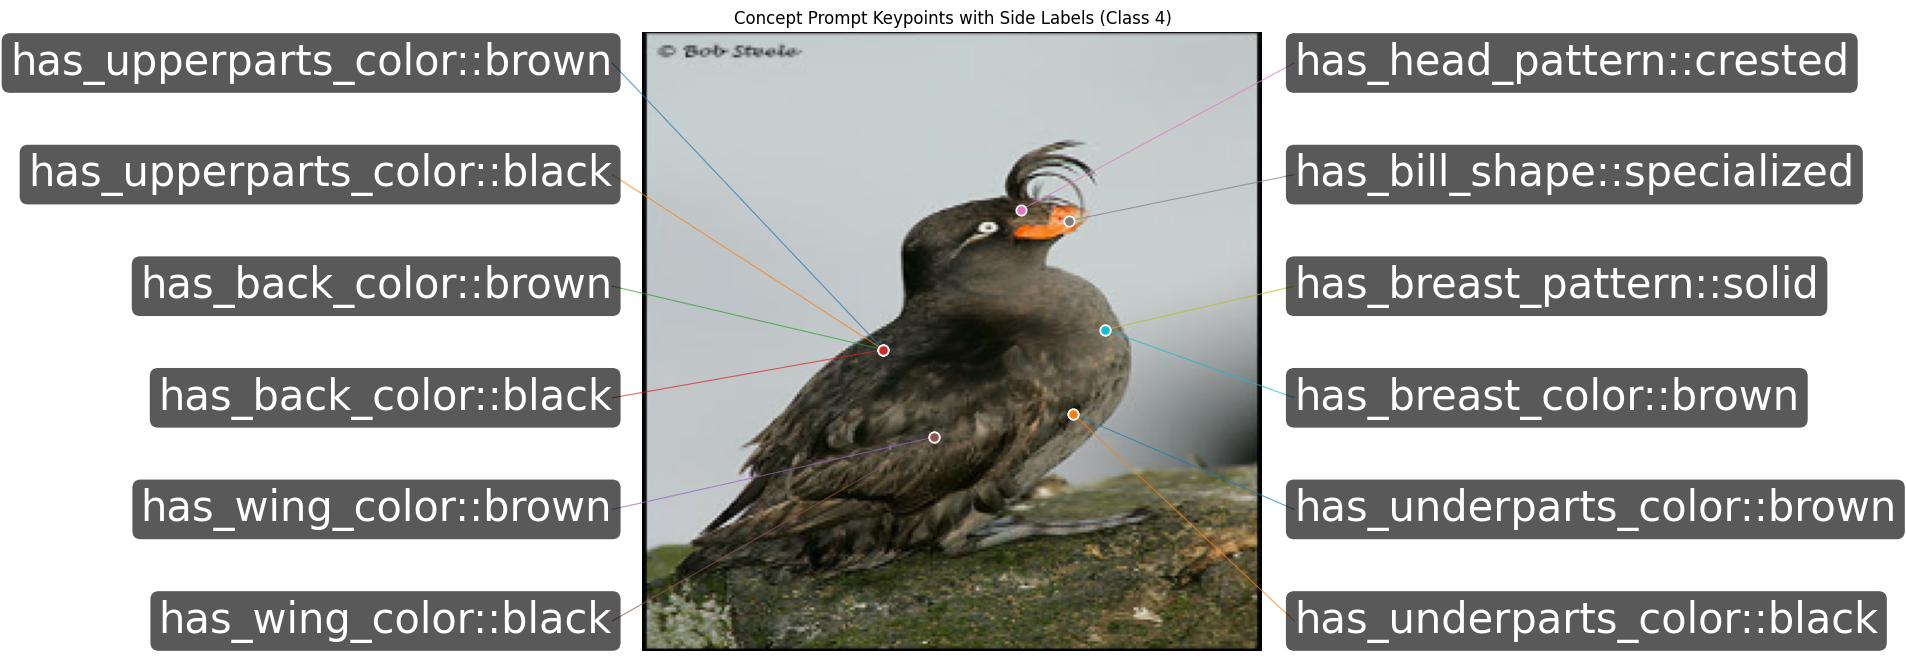

In [ ]:
plot_concept_prompts_side_labels(bird, dataset.concepts, max_labels=12)

In [ ]:
# Weißraum um das Bild minimieren (wichtig für das Layout im Paper)
plt.savefig(
    "cub312_concept_visualization.pdf", 
    format="pdf", 
    bbox_inches="tight", 
    pad_inches=0.05,
    transparent=True
)
plt.close() # Schließt die Figure, um Speicher zu sparen

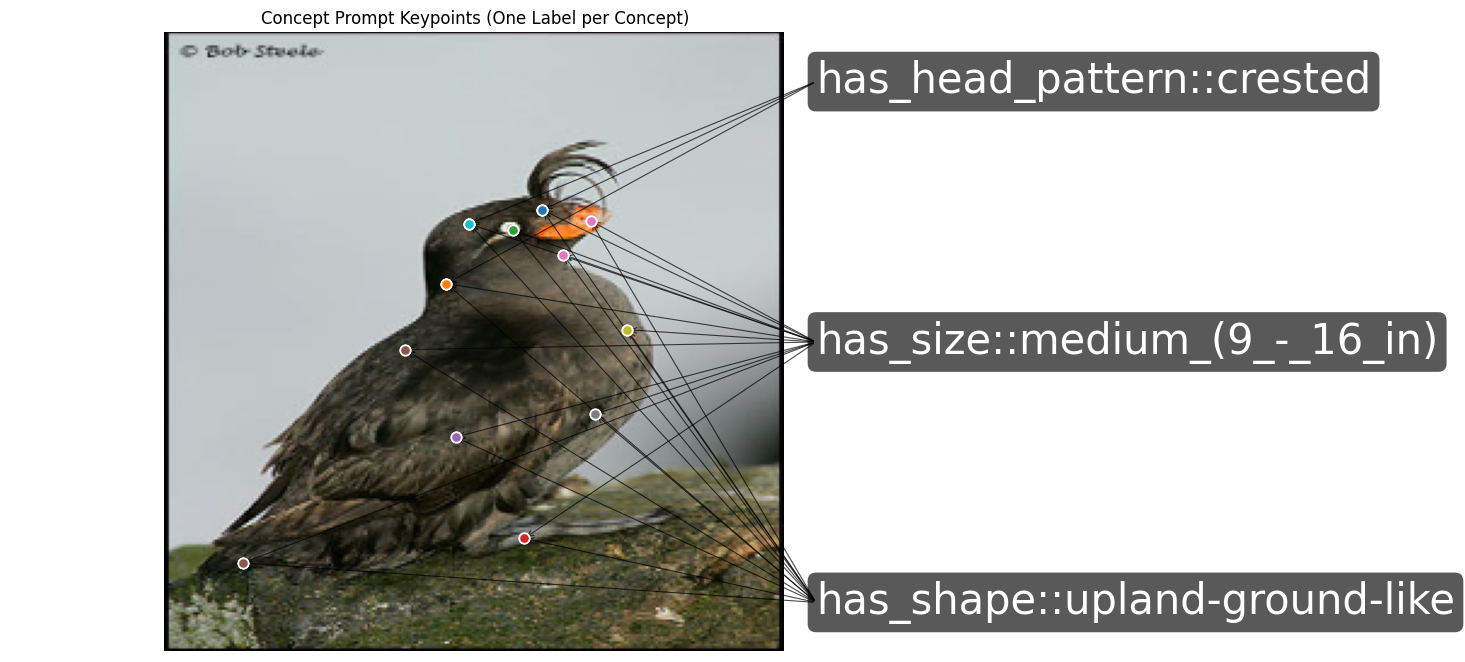

In [ ]:
plot_concept_prompts_single_label(bird, dataset.concepts)

In [ ]:
# Weißraum um das Bild minimieren (wichtig für das Layout im Paper)
plt.savefig(
    "cub312_concept_visualization_multiple_parts.pdf", 
    format="pdf", 
    bbox_inches="tight", 
    pad_inches=0.05,
)
plt.close() # Schließt die Figure, um Speicher zu sparen

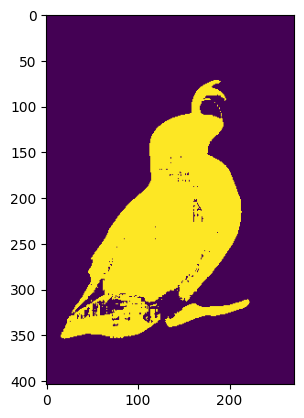

In [ ]:
plt.imshow(bird['mask_concepts'].any(axis=0))